## Import

In [1]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import halfnorm, norm
import copy
import pandas as pd
import time
import numpy as np
from voting import get_votes,generate_observations,generate_candidates,individual_vote
import altair as alt
import matplotlib.pyplot as plt
import colorsys
import altair as alt

# Import JAX and related modules
from jax import jit
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial

# Round one

## Parameters

In [2]:
# Parameters for the simulation
n_candidates = 12 
n_preferences = 10
n_agents = 100000  # Number of agents in the simulation

# Generate observations using the generate_observations function
input_data = generate_observations(n_nodes=n_preferences, n_steps=100, scenario=1) # good scenario
#input_data = generate_observations(n_nodes=n_preferences, n_steps=5000, scenario=2, shock_pattern= "sudden",shock_time=100,recovery_time=200) # bad scenario

# Generate tonic volatilities for agents using a normal distribution
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)

# Generate candidate
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)

mask = np.ones(n_candidates)


In [3]:
candidate_list

[(array([3.75961144, 1.43815413, 2.68907946, 1.91661244, 2.12987677,
         1.77335098, 0.92819282, 0.80423713, 0.9731542 , 1.86250005]),
  array([0.7612714 , 1.78406725, 0.25536521, 0.82147381, 0.44203763,
         1.30959197, 1.82965752, 1.21293893, 0.82896905, 0.00803431])),
 (array([3.91532594, 2.92649202, 1.90932466, 2.739664  , 3.04081198,
         1.37864448, 1.58704236, 2.75280359, 1.24196321, 2.70074384]),
  array([1.04982619, 0.31009968, 0.35182099, 0.49160396, 0.92218926,
         1.35095243, 0.24119121, 0.81893535, 0.55420381, 0.34537723])),
 (array([-0.18513708,  0.30389301,  1.54462607,  3.46099275,  1.41178845,
          0.15237773,  2.56171456,  3.59131767,  2.04408229,  1.10991458]),
  array([0.58666097, 1.09877601, 2.76690302, 0.92441226, 0.21225081,
         0.34562465, 1.13029675, 0.09454395, 0.67094678, 1.96279078])),
 (array([1.17286566, 2.46697052, 1.55145186, 1.39769801, 0.73869304,
         1.42980269, 2.20106174, 0.8199838 , 2.8978817 , 2.18068068]),
  array

## Agents

In [4]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

# Loop to sample and store tuples
mus, pis = [], []
for _ in range(n_preferences):
    mus.append(norm.rvs(2, 1))
    pis.append(halfnorm.rvs(0, 1))
network.attributes[-1]["preferences"] = {
    "mean": np.array(mus), 
    "precision": np.array(pis)
}

# get continuous nodes matching preferences
preferences_idx = [
        network.edges[idx].value_parents[0] for idx in network.input_idxs
    ]

In [5]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    preferences_idx=preferences_idx,
    input_data=input_data,
    mask=mask
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes = vmap_get_votes_fn(tonic_volatilities, keys)
# Split into 10 simulations
simulations = np.array_split(votes, 100)

In [6]:
# Prepare a list to store proportions for each simulation
rows = []

for i, sim in enumerate(simulations):
    total_votes = len(sim)
    unique, counts = np.unique(sim, return_counts=True)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–10
            'candidate': candidate,
            'proportion': count / total_votes
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,candidate_id
0,1,0,0.061,0
1,1,1,0.033,1
2,1,2,0.016,2
3,1,3,0.221,3
4,1,5,0.064,5
...,...,...,...,...
1027,100,7,0.003,7
1028,100,8,0.196,8
1029,100,9,0.036,9
1030,100,10,0.001,10


In [7]:
# Define a color scale based on all candidates
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Define interactive highlight on mouseover
highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')

# Create area chart
chart = alt.Chart(df_simulations).mark_area(opacity=0.85).encode(
    x=alt.X('simulation_number:N', title='Simulation Number'),
    y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
    color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),
    tooltip=[
        alt.Tooltip('candidate:N', title='Candidate'),
        alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
        alt.Tooltip('simulation_number:N', title='Simulation')
    ]
).add_selection(highlight).properties(
    width=1000,
    height=250,
    title="Evolution of Vote Proportions – Simulations"
)

chart

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20241/737925221.py:6: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20241/737925221.py:19: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(highlight).properties(


alt.Chart(...)

# Round two

In [8]:
# For each simulation select the two best candidates
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)
best_two_candidates

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20241/2205060293.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))


,simulation_number,candidate,proportion,candidate_id
9,1,11,0.259,11
7,1,8,0.223,8
19,2,11,0.242,11
13,2,3,0.225,3
30,3,11,0.268,11
...,...,...,...,...
1003,98,3,0.226,3
1020,99,11,0.267,11
1013,99,3,0.227,3
1031,100,11,0.264,11


In [9]:
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)
tonic_volatilities_chunks[99]

array([-1.39523254, -5.21029916, -3.82450431, -3.69421795, -3.39428894,
       -2.18594885, -4.373066  , -4.62235744, -3.87754834, -3.22122712,
       -2.44062522, -2.95351449, -1.69555574, -0.45136546, -2.7494162 ,
       -1.97060454, -2.47134695, -3.13990817, -3.3338778 , -2.47149325,
       -3.04179258, -3.14919102, -3.62317527, -1.24926956, -2.7911558 ,
       -3.2177343 , -2.03106918, -2.14097172, -3.44806032, -4.26569482,
       -3.42811385, -4.35249558, -1.85747302, -5.17560903, -3.03199905,
       -3.32705294, -3.25926264, -2.11565353, -2.67277453, -4.65225059,
       -1.64945024, -3.99909196, -4.40892953, -2.81872311, -5.28739175,
       -1.82545277, -4.79727978, -3.30351204, -3.53361819, -2.05842742,
       -2.19131785, -4.15745399, -1.71849701, -4.3064247 , -3.22103704,
       -2.8960796 , -2.33962076, -1.90946035, -3.10136706, -4.55150904,
       -3.61371573, -4.2873481 , -2.99047151, -3.32835708, -1.49085218,
       -2.02604192, -1.20490852, -2.29426509, -2.86088408, -2.85

In [ ]:
≈

100000

In [ ]:
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)
n_agents = 100
import jax.numpy as jnp
for simulation in range(len(simulations)):
    # take two candidates for this simulation
    best_two_candidates = simulations[simulation]

    # build JAX mask (True = keep, False = mask out)
    mask = jnp.zeros(n_candidates, dtype=bool).at[best_two_candidates].set(True)

    tonic_volatilities = tonic_volatilities_chunks[simulation - 1]

    # Setup and vectorize the get_votes function
    get_votes_fn = Partial(
        individual_vote,
        network=network,
        candidates=candidate_list,
        preferences_idx=preferences_idx,
        input_data=input_data,
        mask=mask,
    )
    vmap_get_votes_fn = vmap(get_votes_fn)

    # Random keys for each agent
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)

    # Compute votes
    votes = vmap_get_votes_fn(tonic_volatilities, keys)

    # Store results in DataFrame
    df_votes = pd.DataFrame(votes)


ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 100: axis 0 of argument tonic_volatility of type float32[100];
  * one axis had size 100000: axis 0 of argument key of type uint32[100000,2]

In [ ]:
# par tranche de 100
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)


100000

# Plot trajectories

NameError: name 'nodes_traje' is not defined

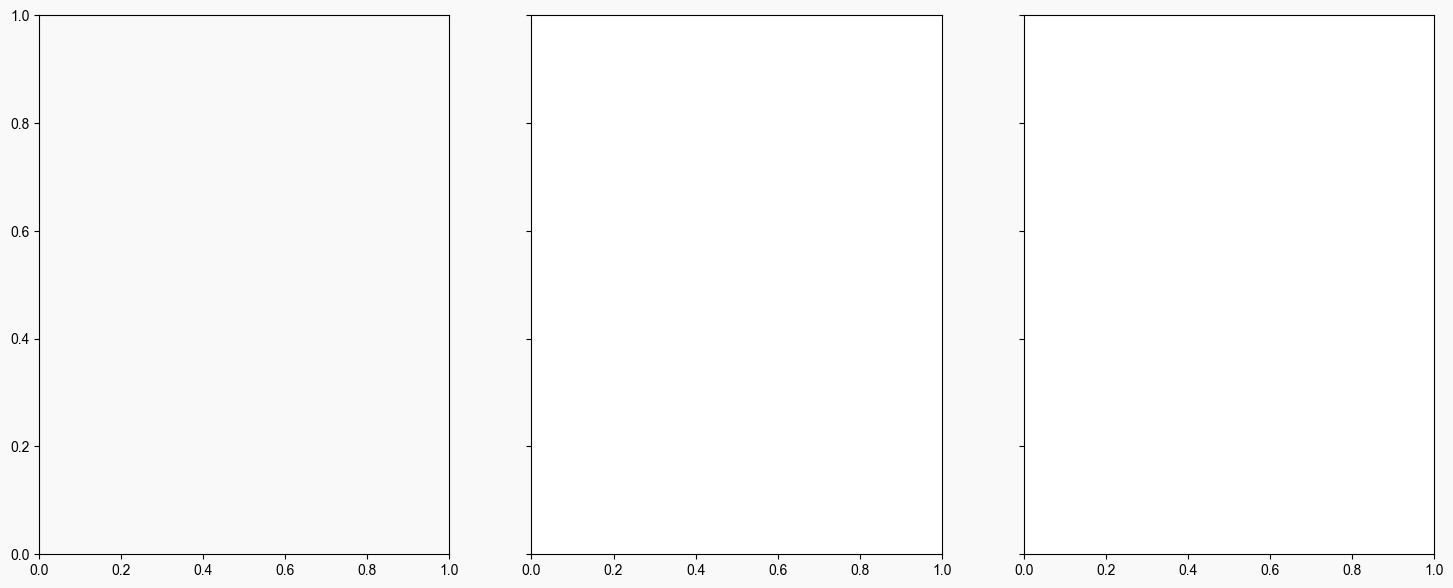

In [ ]:
# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 3']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(n_agents)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agents in range(n_agents):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agents]
        # Définir la transparence
        alpha = 0.4 + 0.6 * (n_agents / (n_agents+1))  # Safe range: 0.4–1.0

        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agents],
            label=f'Agent {n_agents + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agents % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()


# TO ADD
- Decision-Making Algorithm
- Environement (Manages agents, election rules, results, information, and simulation steps)
- 